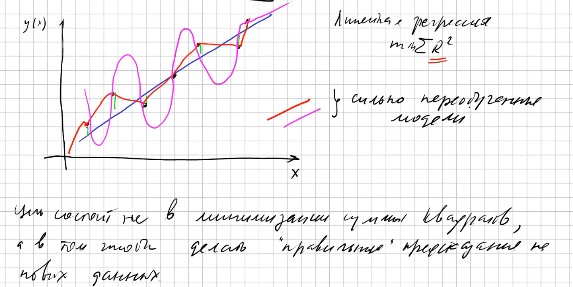

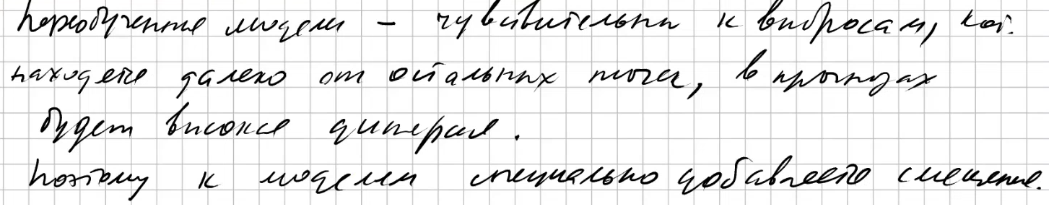

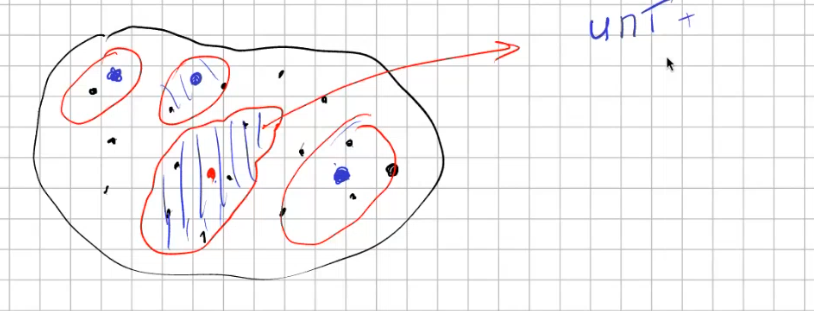

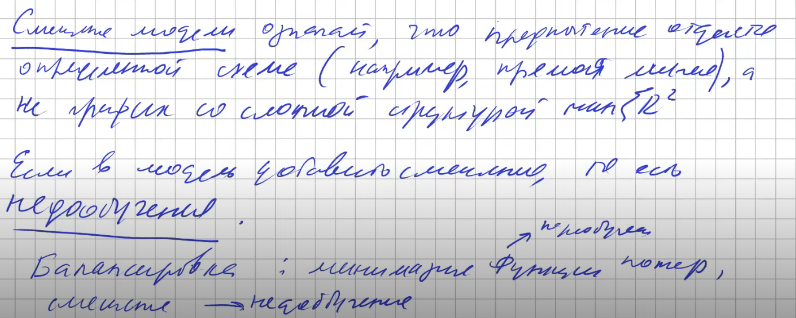

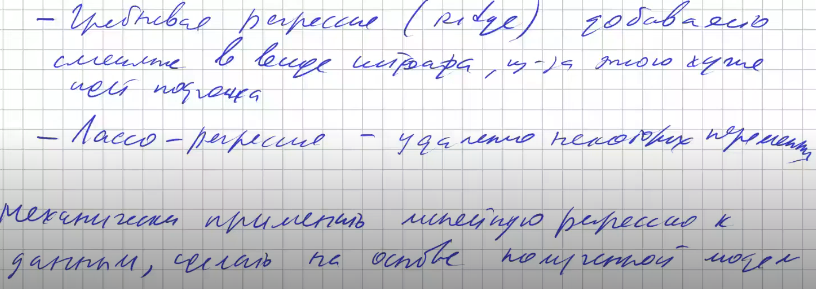

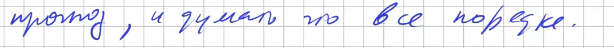

In [25]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
import matplotlib.pyplot as plt

In [17]:
data = np.array(
    [
        [1, 5], 
        [2, 7], 
        [3, 7], 
        [4, 10], 
        [5, 11], 
        [6, 14], 
        [7, 17], 
        [8, 19], 
        [9, 22], 
        [10, 28]
    ]
)


# Градиентный спуск - пакетный градиентный спуск. Для работы использу.тся ВСЕ доступные обучающие данные
# Стохастический градиентный спус, на каждой итерации обучаемся только по одной выборке из данных
# - сокращение числа вычислений
# - вносим смещение => боремся с переобучением
# Мини-пакетный градиентный спуск, на каждой итерации используется несколько выборок

x = data[:, 0]
y = data[:, 1]
n = len(x)

w1 = 0.0
w0 = 0.0

L = 0.001

# размер выборки
sample_size = 1

iterations = 100_000

for i in range(iterations):
    idx = np.random.choice(n, sample_size, replace=False)
    D_w0 = 2 * sum((-y[idx] + w0 + w1 * x[idx]))
    D_w1 = 2 * sum(x[idx] * (-y[idx] + w0 + w1 * x[idx]))
    w1 -= L * D_w1
    w0 -= L * D_w0

print(w1, w0)

2.382974735795803 0.8193650865891935


In [7]:
# Как оценить насколько сильно "промахиваются" прогнозы при использованиии линейной регрессии

data_df = pd.DataFrame(data)
print(data_df.corr(method='pearson'))

         0        1
0  1.00000  0.97684
1  0.97684  1.00000


In [11]:
data_df[1] = data_df[1].values[::-1]
print(data_df.corr(method='pearson'))

         0        1
0  1.00000  0.97684
1  0.97684  1.00000


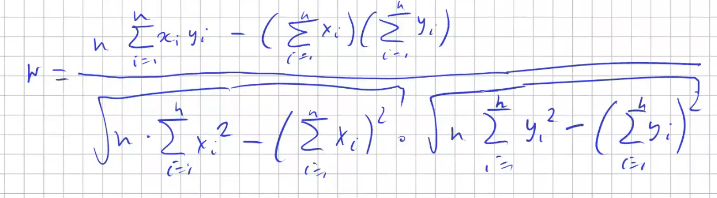

In [12]:
# Коэффициент корреляции помогает понять, есть ли связь между двумя переменными.
# Обучающие и тестовые выборки
# Основной метод больбы с переобучением, заключается в том, что набор данных делится на обучающую и тестовую выборки.abs
# Во всех видах машинного обучения с учителем это встречается
# Обычная пропорция 2/3 - на обучение, 1/3 на тест. (4/5 к 1/5, 9/10 к 1/10)

In [21]:
X = data_df.values[:,:-1]
Y = data_df.values[:,-1]
print(X)
print(Y)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 1/3)
print(X_train)
print(Y_train)

print(X_test) 
print(Y_test)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[ 5  7  7 10 11 14 17 19 22 28]
[[ 4]
 [ 2]
 [ 5]
 [10]
 [ 6]
 [ 8]]
[10  7 11 28 14 19]
[[7]
 [9]
 [3]
 [1]]
[17 22  7  5]


In [33]:
kfold = KFold(n_splits=3, random_state=1, shuffle=True) # 3-х кратная перекрестная валидация

model = LinearRegression()
#model.fit(X_train, Y_train)
results = cross_val_score(model, X, Y, cv=kfold)
print(results) # средне квадратические ошибки
print(results.mean(), results.std())

# r = model.score(X_test, Y_test)
# print(r)

[ 0.88414769 -2.35154626  0.75792214]
-0.23649214168138702 1.4964566263570538


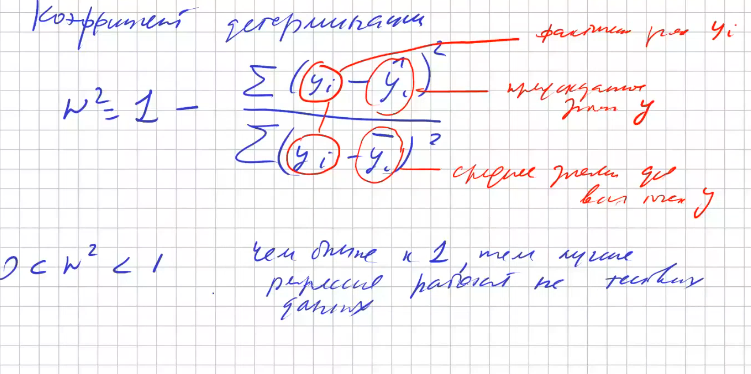

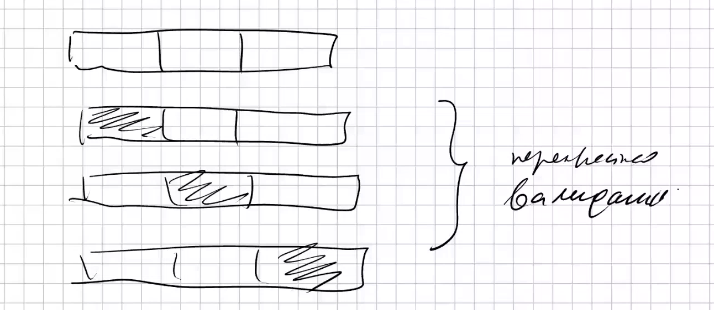

In [34]:
# Метрики показывают насклько ЕДИНООБРАЗНО ведет себя модель на разных выборках

# Возможно использование поэлементной перекрестной валидации мало данных 
# Случайную валидацию
# Валидационная выборка для сравнения различных моделей или конфигураций

In [37]:
data_df = pd.read_csv('multiple_independent_variable_linear.csv')
print(data_df.head())

   x1  x2   y
0   0  22  88
1   1  13  62
2   1  15  67
3   1  14  62
4   2  18  77


[2.00672647 3.00203798] 20.10943282003599


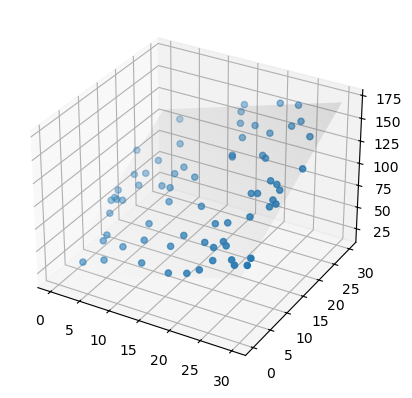

In [44]:
X = data_df.values[:,:-1] 
Y = data_df.values[:, -1]

model = LinearRegression().fit(X, Y)

print(model.coef_, model.intercept_)

x1 = X[:, 0]
x2 = X[:, 1]
y = Y

fig= plt.figure()
ax = plt.axes(projection="3d") 
ax.scatter3D(x1, x2, y)

x1_ = np.linspace(min(x1), max(x1), 100)
x2_ = np.linspace(min(x1), max(x1), 100)

X1_, X2_ = np.meshgrid(x1_, x2_)

Y_ = model.intercept_ + model.coef_[0] * X1_ + model.coef_[1] * X2_

ax.plot_surface(X1_, X2_, Y_, cmap='Greys', alpha=0.1)

plt.show()